In [ ]:
!git clone https://github.com/hossambalaha/hmbd-v1.git

Cloning into 'hmbd-v1'...
remote: Enumerating objects: 54242, done.
remote: Counting objects: 100% (7/7), done.
remote: Compressing objects: 100% (6/6), done.
remote: Total 54242 (delta 1), reused 3 (delta 1), pack-reused 54235 (from 1)
Receiving objects: 100% (54242/54242), 230.97 MiB | 20.20 MiB/s, done.
Resolving deltas: 100% (2128/2128), done.
Updating files: 100% (54119/54119), done.


In [ ]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import cv2

In [ ]:
img_width, img_height = 150, 150

data_dir = '/content/hmbd-v1/Dataset'

images = []
labels = []

digits = ['Zero', 'One', 'Two', 'Three', 'Four', 'Five', 'Six', 'Seven', 'Eight', 'Nine']

for label, digit in enumerate(digits):
    digit_dir = os.path.join(data_dir, digit)

    if os.path.isdir(digit_dir):
        num_images = len(os.listdir(digit_dir))
        print(f"Number of images in '{digit}': {num_images}")
        for img_name in os.listdir(digit_dir):
            img_path = os.path.join(digit_dir, img_name)
            image = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
            image = cv2.resize(image, (img_width, img_height))
            images.append(image)
            labels.append(label)

images = np.array(images).reshape(-1, img_width, img_height, 1) / 255.0
labels = to_categorical(np.array(labels), len(digits))

x_train, x_test, y_train, y_test = train_test_split(images, labels, test_size=0.2, random_state=42)


Number of images in 'Zero': 480
Number of images in 'One': 465
Number of images in 'Two': 468
Number of images in 'Three': 466
Number of images in 'Four': 468
Number of images in 'Five': 464
Number of images in 'Six': 489
Number of images in 'Seven': 474
Number of images in 'Eight': 488
Number of images in 'Nine': 474


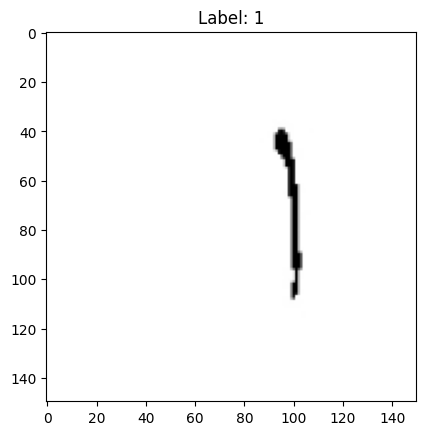

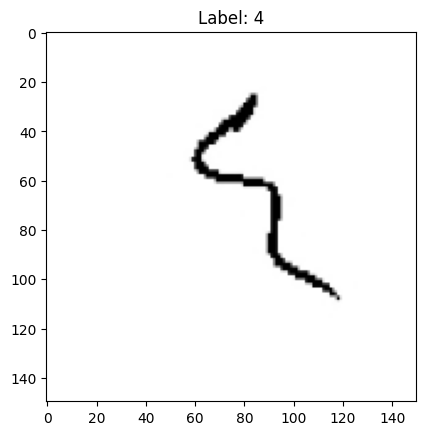

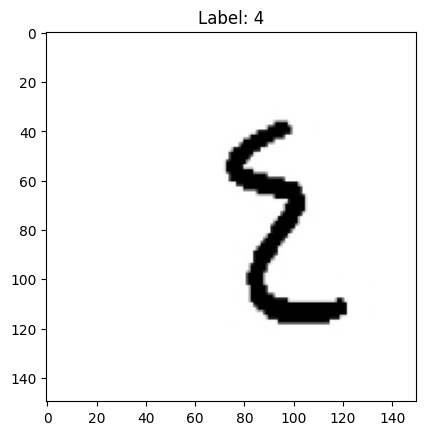

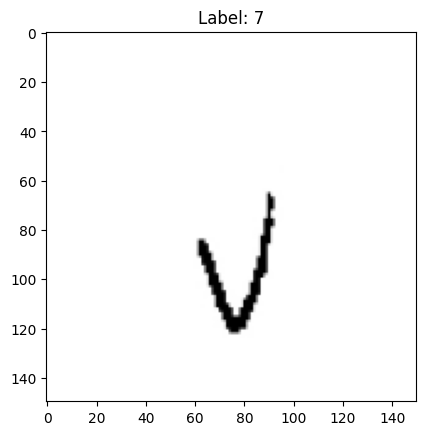

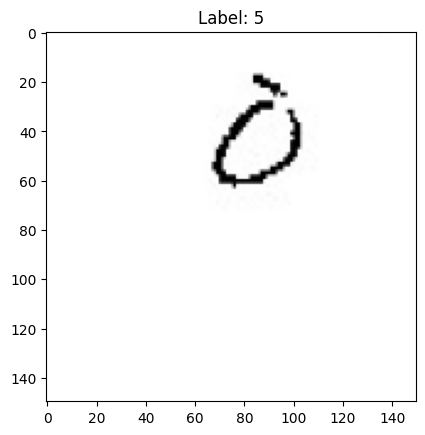

In [ ]:
for i in range(5):
    plt.imshow(x_train[i].reshape(img_width, img_height), cmap='gray')
    plt.title(f"Label: {np.argmax(y_train[i])}")
    plt.show()

In [ ]:

datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.1,
    fill_mode='nearest'
)

train_generator = datagen.flow(x_train, y_train, batch_size=32)


In [ ]:
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(img_width, img_height, 1)),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(256, activation='relu'),
    Dense(10, activation='softmax')
])

learning_rate = 0.00001
optimizer = Adam(learning_rate=learning_rate)

model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])


lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1)

early_stopping = EarlyStopping(monitor='val_loss',patience=5,restore_best_weights=True,verbose=1)

history = model.fit(
    x_train, y_train,
    epochs=20,
    validation_data=(x_test, y_test),
    callbacks=[lr_scheduler, early_stopping]
)





/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 17s 58ms/step - accuracy: 0.1052 - loss: 2.3059 - val_accuracy: 0.1340 - val_loss: 2.2914 - learning_rate: 1.0000e-05
Epoch 2/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - accuracy: 0.1450 - loss: 2.2876 - val_accuracy: 0.1551 - val_loss: 2.2628 - learning_rate: 1.0000e-05
Epoch 3/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - accuracy: 0.2052 - loss: 2.2478 - val_accuracy: 0.2954 - val_loss: 2.1952 - learning_rate: 1.0000e-05
Epoch 4/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - accuracy: 0.3216 - loss: 2.1674 - val_accuracy: 0.3903 - val_loss: 2.0643 - learning_rate: 1.0000e-05
Epoch 5/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - accuracy: 0.3922 - loss: 2.0100 - val_accuracy: 0.4156 - val_loss: 1.9177 - learning_rate: 1.0000e-05
Epoch 6/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - accuracy: 0.4187 - loss: 1.8824 - val_accuracy: 0.4462 - val_loss: 1.8070 - learning_rate: 1.0000e-05
Epoch 7/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/step - ac

In [ ]:
train_loss = history.history['loss'][-1]
test_loss, test_accuracy = model.evaluate(x_test, y_test, verbose=0)
print(f"Training Loss: {train_loss:.4f}")
print(f"Test Loss: {test_loss:.4f}")

train_accuracy = history.history['accuracy'][-1]
print(f"Training Accuracy: {train_accuracy * 100:.2f}%")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")



Training Loss: 1.0728
Test Loss: 1.2216
Training Accuracy: 67.77%
Test Accuracy: 64.45%


increase learning rete

In [ ]:
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(img_width, img_height, 1)),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(256, activation='relu'),
    Dense(10, activation='softmax')
])

learning_rate = 0.0001
optimizer = Adam(learning_rate=learning_rate)

model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])


lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1)

early_stopping = EarlyStopping(monitor='val_loss',patience=5,restore_best_weights=True,verbose=1)

history = model.fit(
    x_train, y_train,
    epochs=20,
    validation_data=(x_test, y_test),
    callbacks=[lr_scheduler, early_stopping]
)





Epoch 1/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 9s 47ms/step - accuracy: 0.1239 - loss: 2.2859 - val_accuracy: 0.3671 - val_loss: 1.9086 - learning_rate: 1.0000e-04
Epoch 2/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 7s 27ms/step - accuracy: 0.3880 - loss: 1.7951 - val_accuracy: 0.5169 - val_loss: 1.5480 - learning_rate: 1.0000e-04
Epoch 3/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - accuracy: 0.5373 - loss: 1.4270 - val_accuracy: 0.5770 - val_loss: 1.3351 - learning_rate: 1.0000e-04
Epoch 4/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/step - accuracy: 0.6721 - loss: 1.0844 - val_accuracy: 0.6730 - val_loss: 1.0699 - learning_rate: 1.0000e-04
Epoch 5/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - accuracy: 0.7530 - loss: 0.8341 - val_accuracy: 0.7236 - val_loss: 0.9064 - learning_rate: 1.0000e-04
Epoch 6/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - accuracy: 0.8310 - loss: 0.5716 - val_accuracy: 0.7711 - val_loss: 0.8124 - learning_rate: 1.0000e-04
Epoch 7/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - acc

In [ ]:
train_loss = history.history['loss'][-1]
test_loss, test_accuracy = model.evaluate(x_test, y_test, verbose=0)
print(f"Training Loss: {train_loss:.4f}")
print(f"Test Loss: {test_loss:.4f}")

train_accuracy = history.history['accuracy'][-1]
print(f"Training Accuracy: {train_accuracy * 100:.2f}%")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")



Training Loss: 0.0423
Test Loss: 0.6244
Training Accuracy: 99.58%
Test Accuracy: 84.70%


put droupout


In [ ]:
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(img_width, img_height, 1)),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.4),
    Dense(10, activation='softmax')
])

learning_rate = 0.0001
optimizer = Adam(learning_rate=learning_rate)

model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])


lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1)

early_stopping = EarlyStopping(monitor='val_loss',patience=5,restore_best_weights=True,verbose=1)

history = model.fit(
    x_train, y_train,
    epochs=20,
    validation_data=(x_test, y_test),
    callbacks=[lr_scheduler, early_stopping]
)





/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 10s 58ms/step - accuracy: 0.1095 - loss: 2.3014 - val_accuracy: 0.3312 - val_loss: 2.0412 - learning_rate: 1.0000e-04
Epoch 2/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - accuracy: 0.3557 - loss: 1.9222 - val_accuracy: 0.5464 - val_loss: 1.5429 - learning_rate: 1.0000e-04
Epoch 3/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - accuracy: 0.5010 - loss: 1.5048 - val_accuracy: 0.6572 - val_loss: 1.1896 - learning_rate: 1.0000e-04
Epoch 4/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.6497 - loss: 1.1292 - val_accuracy: 0.7194 - val_loss: 0.8976 - learning_rate: 1.0000e-04
Epoch 5/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - accuracy: 0.7431 - loss: 0.8419 - val_accuracy: 0.7795 - val_loss: 0.7419 - learning_rate: 1.0000e-04
Epoch 6/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - accuracy: 0.7925 - loss: 0.6602 - val_accuracy: 0.8080 - val_loss: 0.6482 - learning_rate: 1.0000e-04
Epoch 7/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - ac

In [ ]:
train_loss = history.history['loss'][-1]
test_loss, test_accuracy = model.evaluate(x_test, y_test, verbose=0)
print(f"Training Loss: {train_loss:.4f}")
print(f"Test Loss: {test_loss:.4f}")

train_accuracy = history.history['accuracy'][-1]
print(f"Training Accuracy: {train_accuracy * 100:.2f}%")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")



Training Loss: 0.1114
Test Loss: 0.4935
Training Accuracy: 96.83%
Test Accuracy: 85.86%


increase dropout

In [ ]:
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(img_width, img_height, 1)),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.6),
    Dense(10, activation='softmax')
])

learning_rate = 0.0001
optimizer = Adam(learning_rate=learning_rate)

model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])


lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1)

early_stopping = EarlyStopping(monitor='val_loss',patience=5,restore_best_weights=True,verbose=1)

history = model.fit(
    x_train, y_train,
    epochs=20,
    validation_data=(x_test, y_test),
    callbacks=[lr_scheduler, early_stopping]
)





Epoch 1/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 9s 48ms/step - accuracy: 0.1191 - loss: 2.3117 - val_accuracy: 0.3143 - val_loss: 2.1253 - learning_rate: 1.0000e-04
Epoch 2/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - accuracy: 0.2999 - loss: 2.0270 - val_accuracy: 0.4895 - val_loss: 1.6761 - learning_rate: 1.0000e-04
Epoch 3/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - accuracy: 0.4130 - loss: 1.6867 - val_accuracy: 0.5485 - val_loss: 1.4156 - learning_rate: 1.0000e-04
Epoch 4/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - accuracy: 0.4895 - loss: 1.4759 - val_accuracy: 0.6709 - val_loss: 1.1729 - learning_rate: 1.0000e-04
Epoch 5/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - accuracy: 0.5835 - loss: 1.2403 - val_accuracy: 0.7194 - val_loss: 0.9951 - learning_rate: 1.0000e-04
Epoch 6/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - accuracy: 0.6385 - loss: 1.1000 - val_accuracy: 0.7722 - val_loss: 0.8380 - learning_rate: 1.0000e-04
Epoch 7/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - acc

In [ ]:
train_loss = history.history['loss'][-1]
test_loss, test_accuracy = model.evaluate(x_test, y_test, verbose=0)
print(f"Training Loss: {train_loss:.4f}")
print(f"Test Loss: {test_loss:.4f}")

train_accuracy = history.history['accuracy'][-1]
print(f"Training Accuracy: {train_accuracy * 100:.2f}%")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")



Training Loss: 0.2760
Test Loss: 0.4691
Training Accuracy: 90.65%
Test Accuracy: 87.34%


Increase dropout

In [ ]:
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(img_width, img_height, 1)),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.7),
    Dense(10, activation='softmax')
])

learning_rate = 0.0001
optimizer = Adam(learning_rate=learning_rate)

model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])


lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1)

early_stopping = EarlyStopping(monitor='val_loss',patience=5,restore_best_weights=True,verbose=1)

history = model.fit(
    x_train, y_train,
    epochs=40,
    validation_data=(x_test, y_test),
    callbacks=[lr_scheduler, early_stopping]
)





/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/40
119/119 ━━━━━━━━━━━━━━━━━━━━ 9s 46ms/step - accuracy: 0.0982 - loss: 2.3278 - val_accuracy: 0.2015 - val_loss: 2.2415 - learning_rate: 1.0000e-04
Epoch 2/40
119/119 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - accuracy: 0.1861 - loss: 2.1769 - val_accuracy: 0.4156 - val_loss: 1.8495 - learning_rate: 1.0000e-04
Epoch 3/40
119/119 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - accuracy: 0.3276 - loss: 1.9125 - val_accuracy: 0.4947 - val_loss: 1.6404 - learning_rate: 1.0000e-04
Epoch 4/40
119/119 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - accuracy: 0.3979 - loss: 1.7455 - val_accuracy: 0.5633 - val_loss: 1.4364 - learning_rate: 1.0000e-04
Epoch 5/40
119/119 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - accuracy: 0.4610 - loss: 1.5517 - val_accuracy: 0.6044 - val_loss: 1.2883 - learning_rate: 1.0000e-04
Epoch 6/40
119/119 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - accuracy: 0.5215 - loss: 1.4120 - val_accuracy: 0.6540 - val_loss: 1.1382 - learning_rate: 1.0000e-04
Epoch 7/40
119/119 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - acc

In [ ]:
train_loss = history.history['loss'][-1]
test_loss, test_accuracy = model.evaluate(x_test, y_test, verbose=0)
print(f"Training Loss: {train_loss:.4f}")
print(f"Test Loss: {test_loss:.4f}")

train_accuracy = history.history['accuracy'][-1]
print(f"Training Accuracy: {train_accuracy * 100:.2f}%")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")



Training Loss: 0.3367
Test Loss: 0.4476
Training Accuracy: 88.12%
Test Accuracy: 86.71%


Increase dropout

In [ ]:
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(img_width, img_height, 1)),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.8),
    Dense(10, activation='softmax')
])

learning_rate = 0.0001
optimizer = Adam(learning_rate=learning_rate)

model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])


lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1)

early_stopping = EarlyStopping(monitor='val_loss',patience=5,restore_best_weights=True,verbose=1)

history = model.fit(
    x_train, y_train,
    epochs=40,
    validation_data=(x_test, y_test),
    callbacks=[lr_scheduler, early_stopping]
)





/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/40
119/119 ━━━━━━━━━━━━━━━━━━━━ 9s 46ms/step - accuracy: 0.1152 - loss: 2.3143 - val_accuracy: 0.1878 - val_loss: 2.2173 - learning_rate: 1.0000e-04
Epoch 2/40
119/119 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - accuracy: 0.2063 - loss: 2.1726 - val_accuracy: 0.4399 - val_loss: 1.9047 - learning_rate: 1.0000e-04
Epoch 3/40
119/119 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - accuracy: 0.3053 - loss: 1.9272 - val_accuracy: 0.4662 - val_loss: 1.7325 - learning_rate: 1.0000e-04
Epoch 4/40
119/119 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - accuracy: 0.4207 - loss: 1.7236 - val_accuracy: 0.6224 - val_loss: 1.3691 - learning_rate: 1.0000e-04
Epoch 5/40
119/119 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - accuracy: 0.4766 - loss: 1.5216 - val_accuracy: 0.6804 - val_loss: 1.1494 - learning_rate: 1.0000e-04
Epoch 6/40
119/119 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - accuracy: 0.5247 - loss: 1.3497 - val_accuracy: 0.7331 - val_loss: 0.9858 - learning_rate: 1.0000e-04
Epoch 7/40
119/119 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - acc

In [ ]:
train_loss = history.history['loss'][-1]
test_loss, test_accuracy = model.evaluate(x_test, y_test, verbose=0)
print(f"Training Loss: {train_loss:.4f}")
print(f"Test Loss: {test_loss:.4f}")

train_accuracy = history.history['accuracy'][-1]
print(f"Training Accuracy: {train_accuracy * 100:.2f}%")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")



Training Loss: 0.3972
Test Loss: 0.4539
Training Accuracy: 85.82%
Test Accuracy: 86.39%


30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step


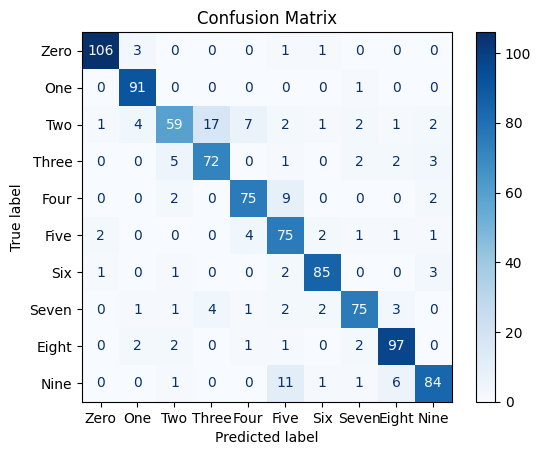

In [ ]:
y_pred = model.predict(x_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

cm = confusion_matrix(y_true_classes, y_pred_classes)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=digits)
disp.plot(cmap='Blues', values_format='d')
plt.title('Confusion Matrix')
plt.show()